# Phishing Email Detection — Machine Learning Demo

This notebook was prepared to demonstrate, **step by step**, how **phishing emails**
can be detected using machine learning.

### Two datasets are used in this notebook

1. **Main dataset — real email text** (`CEAS_08`): Contains the subject and body of
   emails. We build our main model (TF-IDF + Logistic Regression) on this one.
2. **Comparison dataset — numerical features** (`ethancratchley/email-phishing-dataset`):
   Instead of raw email text, it contains 8 pre-extracted numerical features
   (word count, link count, urgent-keyword count...). We use it at the very end for
   a "feature engineering" comparison.


> **Note:** The second dataset has no raw text. Therefore text operations such as
> tokenization / TF-IDF cannot be applied to it. From a teaching perspective, this
> difference is itself a nice learning opportunity: "solving the same problem with
> two different data representations."

---

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")   

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_SEED = 42
print("Libraries ready ✅")

Libraries ready ✅


## 1. What Is Phishing?

### What is spam?
**Spam** is unsolicited bulk email. It is usually promotional (pharma, discounts,
product ads...). It is annoying but, most of the time, not directly dangerous.

### What is phishing?
**Phishing** is fake email that aims to **trick** the user into handing over
sensitive information (passwords, credit cards, banking details). The attacker
usually pretends to be a trusted organization (a bank, a shipping company, an
email provider).

### The difference between the two

| | Spam | Phishing |
|---|---|---|
| **Goal** | Advertising / promotion | Stealing information, fraud |
| **Danger** | Usually low | **High** |
| **Method** | Bulk sending | Impersonation + urgency + fake links |

> Every phishing email can be considered spam, but not every spam is phishing.

### Why is it dangerous in real life?
- You enter your password on a fake "bank" page → your account is drained.
- If a corporate employee is tricked → the **whole company** can be breached.
- Phishing emails are the most common entry point for ransomware.

### Why can machine learning solve this?
Phishing emails contain **recurring patterns**: urgency phrases ("verify now",
"your account has been suspended"), suspicious links, impersonated brand names,
grammar mistakes... These patterns are hard to capture by writing rules one by one;
but a machine learning model **learns them on its own** from thousands of examples.

---

## 2. Load the Dataset (real email text)

Our main dataset contains the **subject** and **body** text of real emails. We load
it via KaggleHub.

In [2]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "naserabdullahalam/phishing-email-dataset",
    "CEAS_08.csv",
)

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (39154, 7)


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    39154 non-null  str  
 1   receiver  38692 non-null  str  
 2   date      39154 non-null  str  
 3   subject   39126 non-null  str  
 4   body      39154 non-null  str  
 5   label     39154 non-null  int64
 6   urls      39154 non-null  int64
dtypes: int64(2), str(5)
memory usage: 2.1 MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sender,39154,24578,qydlqcws-iacfym@issues.apache.org,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
receiver,38692,3693,user6@gvc.ceas-challenge.cc,1375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,39154,38658,"Thu, 07 Aug 2008 21:38:18 -0100",8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject,39126,15436,CNN.com Daily Top 10,2930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,39154,39154,"Buck up, your troubles caused by small dimensi...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,39154.0,NaN,NaN,NaN,0.557848,0.496649,0.0,0.0,1.0,1.0,1.0
urls,39154.0,NaN,NaN,NaN,0.66997,0.47023,0.0,0.0,1.0,1.0,1.0


In [5]:
df.columns

Index(['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls'], dtype='str')

### Meaning of the columns

| Column | Meaning |
|---|---|
| `sender` | Sender email address |
| `receiver` | Recipient email address |
| `date` | Send date |
| `subject` | The **subject** line of the email |
| `body` | The **body** text of the email (the actual content) |
| `urls` | Whether the email contains a link (1/0) |
| `label` | **Our target variable**: `1 = Phishing`, `0 = Safe (normal)` |

The most important columns for us are **`subject`**, **`body`** (input) and
**`label`** (output / what we want to predict).

## 3. Data Analysis (EDA — Exploratory Data Analysis)

In [6]:
# FILL MISSING VALUES
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

# COMBINE SUBJECT + BODY
df["text"] = (df["subject"] + " " + df["body"]).str.strip()

# LABEL ENCODING
df["label_name"] = df["label"].map({0: "Safe", 1: "Phishing"})
df[["subject", "label", "label_name"]].head()

,subject,label,label_name
0,Never agree to be a loser,1,Phishing
1,Befriend Jenna Jameson,1,Phishing
2,CNN.com Daily Top 10,1,Phishing
3,Re: svn commit: r619753 - in /spamassassin/tru...,0,Safe
4,SpecialPricesPharmMoreinfo,1,Phishing


### 3.1 Class distribution (phishing / normal ratio)

label_name
Phishing    21842
Safe        17312
Name: count, dtype: int64

Phishing ratio: %55.8


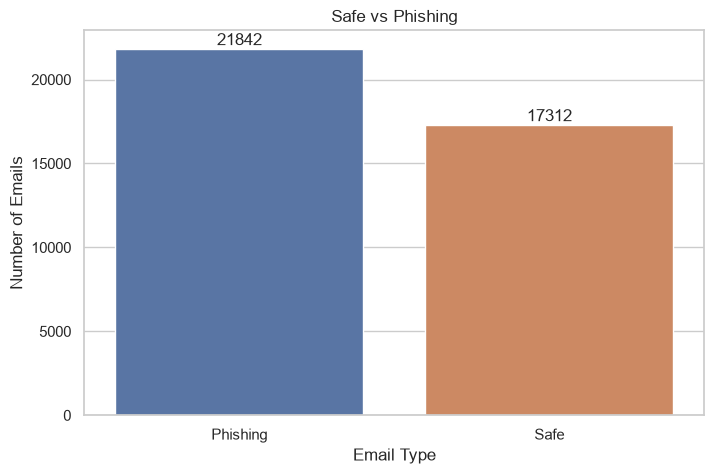

In [7]:
counts = df["label_name"].value_counts()
print(counts)
print("\nPhishing ratio: %{:.1f}".format(100 * df["label"].mean()))

plt.figure()
ax = sns.countplot(data=df, x="label_name", palette=["#4C72B0", "#DD8452"])
ax.set_title("Safe vs Phishing")
ax.set_xlabel("Email Type")
ax.set_ylabel("Number of Emails")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

This dataset is fairly **balanced** (the phishing and safe counts are close to each
other). That is good news: on imbalanced datasets a model can simply memorize the
majority class.

### 3.2 Missing value analysis

In [8]:
missing = df.isnull().sum()
print("Missing values per column:\n")
print(missing)

Missing values per column:

sender          0
receiver      462
date            0
subject         0
body            0
label           0
urls            0
text            0
label_name      0
dtype: int64


### 3.3 Email length

In [9]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)

print("Average character count: {:.0f}".format(df["char_count"].mean()))
print("Average word count  : {:.0f}".format(df["word_count"].mean()))
print()
print("LONGEST email : {} words".format(df["word_count"].max()))
print("SHORTEST email : {} words".format(df["word_count"].min()))

Average character count: 1608
Average word count  : 208

LONGEST email : 19873 words
SHORTEST email : 2 words


In [10]:
en_uzun = df.loc[df["word_count"].idxmax()]
en_kisa = df.loc[df["word_count"].idxmin()]

print("── LONGEST EMAIL ({} words, {}) ──".format(en_uzun["word_count"], en_uzun["label_name"]))
print(en_uzun["text"][:300], "...\n")
print("── SHORTEST EMAIL ({} words, {}) ──".format(en_kisa["word_count"], en_kisa["label_name"]))
print(repr(en_kisa["text"][:300]))

── LONGEST EMAIL (19873 words, Safe) ──
Buzz Alert! Ten things the cool kids are talking about WhatIs.com February 12, 2008 Published by  WhatIs.com THIS ISSUE:   > Buzz Alert!:   What people were talking about while you were working   > In case you missed it:   Because we know you're busy! BUZZ ALERT! ultra wideband   How and why Bluetoo ...

── SHORTEST EMAIL (2 words, Safe) ──
'unsubscribe Unsubscribe'


### 3.4 Word count distribution

Most emails are short and a few are very long. For such distributions, clipping the
outliers makes the chart more readable.

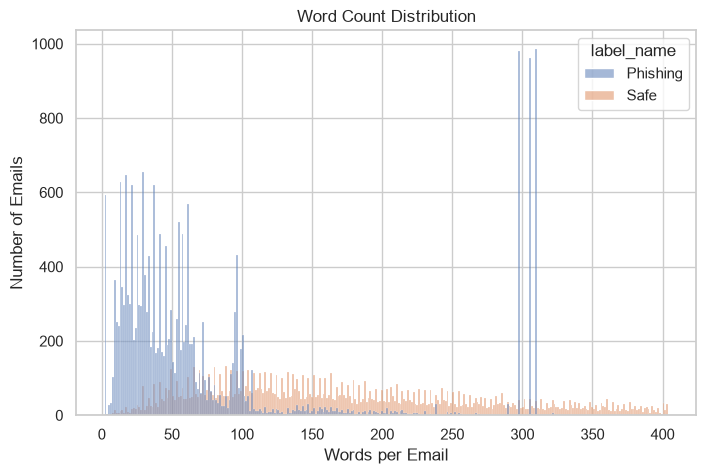

In [11]:
ust_sinir = df["word_count"].quantile(0.90)

plt.figure()
ax = sns.histplot(
    data=df[df["word_count"] <= ust_sinir],
    x="word_count", hue="label_name", bins=300, palette=["#4C72B0", "#DD8452"],
)
ax.set_title("Word Count Distribution")
ax.set_xlabel("Words per Email")
ax.set_ylabel("Number of Emails")
plt.show()

## 4. Real Email Examples

Now let's pick **5 random** safe and 5 phishing emails from the dataset and look at
them.

In [12]:
def ornekleri_goster(veri, etiket_adi, adet=5):
    ornekler = veri[veri["label_name"] == etiket_adi].sample(adet, random_state=RANDOM_SEED)
    for _, satir in ornekler.iterrows():
        konu = (satir["subject"] or "(no subject)").strip()
        govde = satir["body"].strip().replace("\n", " ")
        print("-------------------------")
        print("Label:", etiket_adi)
        print("\nSubject:\n" + konu[:120])
        print("\nBody:\n" + govde[:400] + ("..." if len(govde) > 400 else ""))
        print()

print("===== 5 SAFE (NORMAL) EMAILS =====\n")
ornekleri_goster(df, "Safe")

===== 5 SAFE (NORMAL) EMAILS =====

-------------------------
Label: Safe

Subject:
[SM-DEVEL] SubFolders untranslated

Body:
Hi Everybody, my squirrelmail version is  squirrelmail-1.4.13  i can't translate the INBOX.Sent, INBOX.Drafts and INBOX.Trash  found the left frame of the main window.  everything is translated except those words and they are not included in the squirrelmail.pot also. i have tried to include in my translation strings still the result is the same. please please help me.  Thanks in advance,  Helen

-------------------------
Label: Safe

Subject:
[Python-3000] PEP 3102 question

Body:
Do I understand correctly that with PEP 3102 implemented, keyword arguments can follow vararg in function definitions, but doing the same when calling the function is still a syntax error?  With the latest py3k,  >>> def f(a, *args, v=None): .    pass . >>> f(a, *args, v=None)   File "", line 1     f(a, *args, v=None)                 ^ SyntaxError: invalid syntax  Is this intentional?

In [13]:
print("===== 5 PHISHING EMAILS =====\n")
ornekleri_goster(df, "Phishing")

===== 5 PHISHING EMAILS =====

-------------------------
Label: Phishing

Subject:
The bigger tool

Body:
Dear bbaf0d8f5091008654f086221f7bb1f9  Summer is a exact time to take a break at work and think about your health & personal life.  And we are glad to assist you with it.   From now on till 30th of  October you can use our limited proposal.  Visit our site for further details.  traditionstreet.com  6 Aug 2008 05:05:01

-------------------------
Label: Phishing

Subject:
CNN.com Daily Top 10

Body:
>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug  1, 2008  3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= TOP 10 VIDEOS 1. PARIS HILTON TAKES ON MCCAIN http://www.cnn.com/video/partners/email/index.html?url=/video/politics/2008/08/06/wynter.paris.hilton.ad.cnn Paris Hilton swings back at Repu...

-------------------------
Label: Phishing

Subject:
Satisfy your woman?s craving easily


### Commentary

In the phishing examples we typically see:
- **A sense of urgency:** "now", "your account has been suspended", "within 24 hours".
- **Fake links:** domains that resemble the real organization but are different.
- **Requests for personal information:** password, account verification, payment details.
- **Grammar/spelling mistakes** and a generally "non-corporate" tone.

Safe emails, on the other hand, are usually **informative**, have a clear context,
and do not ask for personal information. For example:

> *"This is the team's weekly newsletter; it does not ask the user for any
> confidential information."*

vs.

> *"This email tries to create a sense of urgency and push the user toward clicking
> a fake link."*

---

## 5. Phishing Signals (Keywords)

Our intuition: some words (verify, account, password, urgent, click, login, bank...)
appear **more often** in phishing emails. Let's confirm this with the data.

In [14]:
# The signal words we want to inspect
belirti_kelimeleri = [
    "http", "https", "verify", "account", "password",
    "urgent", "click", "login", "bank", "update",
]

# For each word, count in how many emails it appears (phishing vs safe)
metin_lower = df["text"].str.lower()

satirlar = []
for kelime in belirti_kelimeleri:
    icerir = metin_lower.str.contains(kelime, regex=False)
    phishing_orani = df.loc[icerir, "label"].mean() * 100 if icerir.any() else 0
    satirlar.append({
        "keyword": kelime,
        "in_phishing": int(((df["label"] == 1) & icerir).sum()),
        "in_safe":  int(((df["label"] == 0) & icerir).sum()),
    })

belirti_df = pd.DataFrame(satirlar).set_index("keyword")
belirti_df

,in_phishing,in_safe
keyword,,
http,14891,11387
https,1,1186
verify,5,239
account,314,1100
password,11,423
urgent,80,55
click,2917,1560
login,11,320
bank,89,240


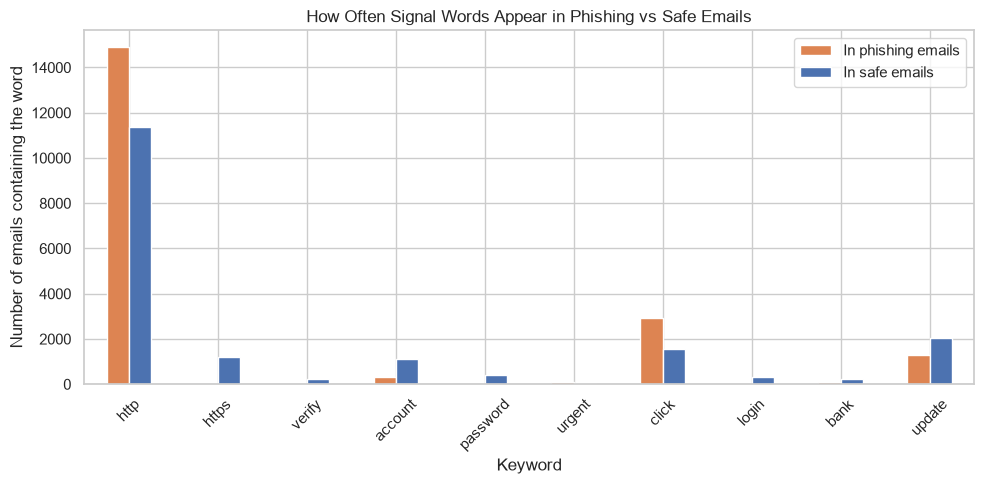

In [15]:
# Compare with a chart
ax = belirti_df.plot(kind="bar", figsize=(10, 5), color=["#DD8452", "#4C72B0"])
ax.set_title("How Often Signal Words Appear in Phishing vs Safe Emails")
ax.set_xlabel("Keyword")
ax.set_ylabel("Number of emails containing the word")
ax.legend(["In phishing emails", "In safe emails"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In the chart we can see that some words (for example *click*, *http*, *update*)
appear noticeably more often in phishing emails. This is exactly the kind of clue
our model will learn — but for **hundreds of words at once**.

---

## 6. Data Preprocessing

A machine learning model does **not understand** raw text; it needs numbers. Before
turning text into a numerical form, we clean it. Below we explain each step and
**why** we do it.

| Step | What it does | Why? |
|---|---|---|
| **Lowercasing** | `Bank` → `bank` | So "Bank" and "bank" count as the same word |
| **Link removal** | `http://...` → removed | Long URLs add noise; their presence matters, not their content |
| **Punctuation removal** | `!,.?` removed | To focus on the words |
| **Whitespace cleanup** | many spaces → one space | For clean tokenization |
| **Tokenization** | text → list of words | The model's "unit" is the word |
| **Stop words** | `the, is, and`... removed | These words are not distinctive |
| **TF-IDF** | word → numeric weight | Highlights rare but distinctive words |

### What is TF-IDF? (in short)
**TF-IDF = Term Frequency × Inverse Document Frequency.**
- If a word appears a lot in one email → it may be important (TF ↑).
- But if that word appears in *every* email (e.g. "the") → it is not distinctive (IDF ↓).

So TF-IDF gives a high weight to "words that are specific and distinctive to this
email.\"

In [16]:
def temizle(metin):
    metin = metin.lower()                           # 1) lowercase
    metin = re.sub(r"http\S+|www\.\S+", " ", metin) # 2) remove links
    metin = re.sub(r"[^a-z\s]", " ", metin)         # 3) remove non-letters
    metin = re.sub(r"\s+", " ", metin).strip()      # 4) collapse extra whitespace
    return metin

# Example: before and after cleaning
ornek = df["text"].iloc[10]
print("BEFORE:", ornek[:160])
print("\nAFTER :", temizle(ornek)[:160])

BEFORE: debt consolidation  
Do Not consolidate your debt   Eliminate it!

Legally ELIMINATE your creditT card and other unsecured debt

* WITHOUT ever making another p

AFTER : debt consolidation do not consolidate your debt eliminate it legally eliminate your creditt card and other unsecured debt without ever making another payment to


In [17]:
df["clean_text"] = df["text"].apply(temizle)
df[["text", "clean_text"]].head(3)

,text,clean_text
0,"Never agree to be a loser Buck up, your troubl...",never agree to be a loser buck up your trouble...
1,Befriend Jenna Jameson \nUpgrade your sex and ...,befriend jenna jameson upgrade your sex and pl...
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,cnn com daily top the daily top from cnn com t...


> **We don't implement tokenization and stop-word removal ourselves:**
> `TfidfVectorizer` will do them for us shortly (it drops stop words via
> `stop_words="english"` and splits the text into words). Using the library's ready,
> well-tested tool is cleaner than "reinventing the wheel." 

## 7. Model

- **80% train**
- **20% test**


**Logistic Regression** is the most common and most interpretable algorithm for
binary classification (0/1). It produces a **probability between 0 and 1** for the
question "Is this email phishing?"
1. Convert the text into a numerical vector with **TF-IDF**.
2. Train Logistic Regression on those vectors.

In [18]:
X = df["clean_text"]   # input: cleaned text
y = df["label"]        # output: 0/1 label

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

print("Training set:", X_train.shape[0], "emails")
print("Test set  :", X_test.shape[0], "emails")

Training set: 31323 emails
Test set  : 7831 emails


In [19]:
# 1) Turn text into numbers: TF-IDF
vectorizer = TfidfVectorizer(
    stop_words="english",    # drop English stop words
    max_features=5000,       # use the 5000 most frequent words (simplicity + speed)
    ngram_range=(1, 2),      # single words + bigrams
)
X_train_tfidf = vectorizer.fit_transform(X_train)   # LEARN + transform on the training set
X_test_tfidf = vectorizer.transform(X_test)         # ONLY transform on the test set

# 2) Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


print("Model trained")
print("Number of TF-IDF features (words):", len(vectorizer.get_feature_names_out()))

Model trained
Number of TF-IDF features (words): 5000


## 9. Results

Let's evaluate the model on the test set.

In [20]:
# Predict on the test set
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]   # phishing probability

print("Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred)))
print("Recall   : {:.4f}".format(recall_score(y_test, y_pred)))
print("F1 Score : {:.4f}".format(f1_score(y_test, y_pred)))

Accuracy : 0.9949
Precision: 0.9950
Recall   : 0.9959
F1 Score : 0.9954


### What do the metrics mean?

- **Accuracy:** What fraction of all predictions are correct? Simple, but it can be
  misleading on imbalanced data.
- **Precision:** Of the ones I labeled "Phishing", how many are **really** phishing?
  If low → many **false alarms** (mistaking a safe email for phishing).
- **Recall:** Of the real phishing emails, how many did I **catch**? If low →
  dangerous phishing emails **slip through**.
- **F1 Score:** The balanced average of Precision and Recall. When you want a single
  "overall success" number, look here.

> In security, **Recall** is usually very important: the cost of missing a phishing
> email is far higher than the cost of mistakenly flagging a safe one.

### Classification Report

In [21]:
print(classification_report(y_test, y_pred, target_names=["Safe", "Phishing"]))

              precision    recall  f1-score   support

        Safe       0.99      0.99      0.99      3462
    Phishing       0.99      1.00      1.00      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



### Confusion Matrix

This matrix shows **where** the model makes mistakes:
- Top-left / bottom-right → **correct** predictions.
- Top-right → we thought a safe email was phishing (false alarm).
- Bottom-left → we missed a phishing email (the most dangerous mistake).

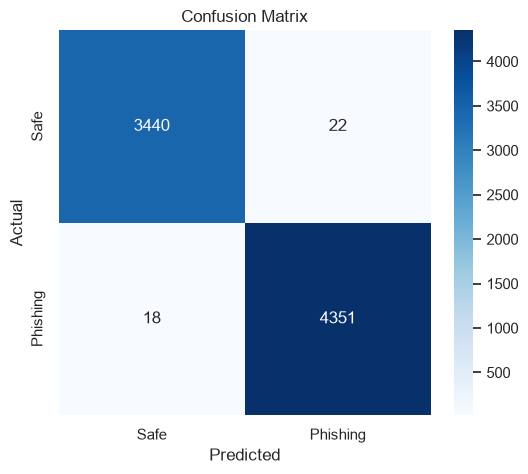

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Safe", "Phishing"],
            yticklabels=["Safe", "Phishing"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ROC Curve

The **ROC curve** shows the trade-off between correct detections and false alarms at
different thresholds. The closer the curve is to the top-left corner, the better the
model. **AUC** (the area under the curve) approaching 1.0 means excellent; 0.5 means
random guessing.

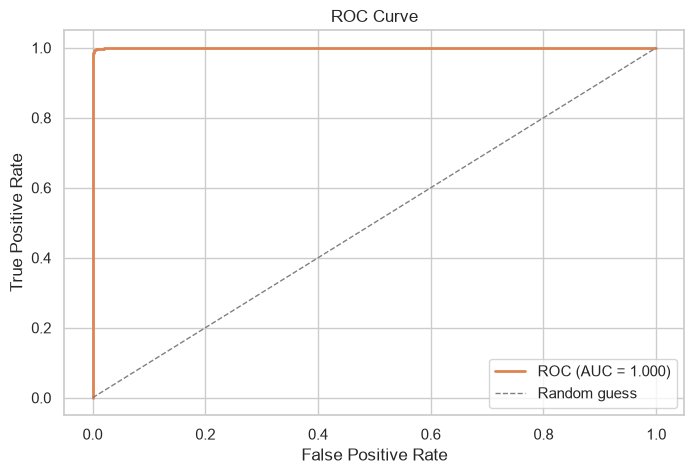

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, color="#DD8452", lw=2, label="ROC (AUC = {:.3f})".format(auc))
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## 10. Try Your Own Email!

Now let's use the model **live**. Write any text into the `email` variable below and
the model will tell you whether it is phishing, and with what probability.

In [24]:
def phishing_mi(email_metni):
    temiz = temizle(email_metni)                 # same cleaning as in section 6
    vec = vectorizer.transform([temiz])           # convert to TF-IDF
    tahmin = model.predict(vec)[0]                # 0 / 1
    olasilik = model.predict_proba(vec)[0][1]     # phishing probability

    etiket = "Phishing" if tahmin == 1 else "Safe"
    print("Prediction\n")
    print(" ", etiket)
    print("\nProbability (phishing): %{:.0f}".format(olasilik * 100))

    # A simple explanation of why: which signal words are present?
    bulunan = [k for k in belirti_kelimeleri if k in temiz]
    print("\nExplanation:")
    if tahmin == 1:
        print("  The model flagged this as phishing.")
        if bulunan:
            print("  Notable words:", ", ".join(bulunan))
        print("  Urgency + requests for personal info/links is a typical phishing pattern.")
    else:
        print("  The model found this safe: weak threat/urgency pattern.")

In [25]:
# ↓↓↓ Write any email you want to test here ↓↓↓
email = """
Dear Customer,

We detected unusual activity on your account. Please verify your account
immediately to avoid suspension. Click the link below and confirm your
password and banking details within 24 hours.

http://secure-verify-login.example.com

Bank Security Team
"""

phishing_mi(email)

Prediction

  Phishing

Probability (phishing): %70

Explanation:
  The model flagged this as phishing.
  Notable words: verify, account, password, click, bank
  Urgency + requests for personal info/links is a typical phishing pattern.


In [26]:
# Second example: a normal, safe email
email_normal = """
Hi team,

Just a reminder that our weekly project sync is tomorrow at 10:00 AM.
The agenda and meeting notes are attached. Let me know if you have anything
to add.

Thanks,
Alex
"""

phishing_mi(email_normal)

Prediction

  Safe

Probability (phishing): %7

Explanation:
  The model found this safe: weak threat/urgency pattern.


In both examples the model makes sensible decisions: the email with urgency +
password/link requests is **phishing**, while an ordinary meeting reminder is
**safe**.

---

## 11. Bonus — A Different Approach: Numerical Features

Until now we used the **raw text** of the email (via TF-IDF). But what if we worked
without ever seeing the text, using only a few **numerical summaries**?

The second dataset we mentioned at the start (`ethancratchley/email-phishing-dataset`)
does exactly this: it represents each email with **8 numbers**: word count, link
count, urgent-keyword count, spelling-error count...

**"Feature Engineering"**

In [27]:
df_num = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ethancratchley/email-phishing-dataset",
    "email_phishing_data.csv",
)
print("Shape:", df_num.shape)
print("Columns:", list(df_num.columns))
df_num.head()

Shape: (524846, 9)
Columns: ['num_words', 'num_unique_words', 'num_stopwords', 'num_links', 'num_unique_domains', 'num_email_addresses', 'num_spelling_errors', 'num_urgent_keywords', 'label']


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


### 11.1 On which features do phishing emails differ?

Let's compare the **average** of each feature for phishing vs safe emails.

                     Safe (0)  Phishing (1)
num_words              276.63        246.15
num_unique_words       122.94        128.30
num_stopwords           80.10         75.71
num_links                0.90          0.42
num_unique_domains       0.35          0.31
num_email_addresses      2.14          0.18
num_spelling_errors     24.77         19.16
num_urgent_keywords      0.24          0.33


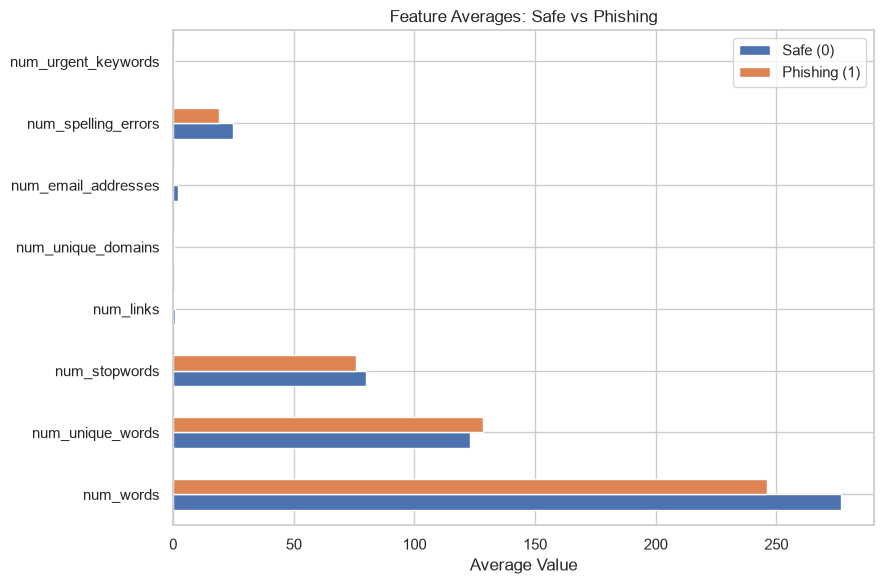

In [28]:
ortalama = df_num.groupby("label").mean().T
ortalama.columns = ["Safe (0)", "Phishing (1)"]
print(ortalama.round(2))

ax = ortalama.plot(kind="barh", figsize=(9, 6), color=["#4C72B0", "#DD8452"])
ax.set_title("Feature Averages: Safe vs Phishing")
ax.set_xlabel("Average Value")
plt.tight_layout()
plt.show()

These 8 numbers are weak at telling phishing apart, because the values are close to
each other — but we'll try anyway.

### 11.2 A model built on these numerical features

This dataset is very **imbalanced** (phishing is only ~1.3%). For a fair comparison
we balance the classes (equal numbers of phishing and safe) and train a small model.

In [29]:
# Balanced subset: all phishing + an equal number of safe
phishing_rows = df_num[df_num["label"] == 1]
safe_rows = df_num[df_num["label"] == 0].sample(len(phishing_rows), random_state=RANDOM_SEED)
balanced = pd.concat([phishing_rows, safe_rows]).sample(frac=1, random_state=RANDOM_SEED)

Xn = balanced.drop(columns="label")
yn = balanced["label"]

Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
    Xn, yn, test_size=0.20, random_state=RANDOM_SEED, stratify=yn
)

scaler = StandardScaler().fit(Xn_tr)
num_model = LogisticRegression(max_iter=1000).fit(scaler.transform(Xn_tr), yn_tr)

yn_pred = num_model.predict(scaler.transform(Xn_te))
print("NUMERICAL FEATURE MODEL (balanced):")
print("  Accuracy : {:.3f}".format(accuracy_score(yn_te, yn_pred)))
print("  Precision: {:.3f}".format(precision_score(yn_te, yn_pred)))
print("  Recall   : {:.3f}".format(recall_score(yn_te, yn_pred)))
print("  F1 Score : {:.3f}".format(f1_score(yn_te, yn_pred)))

NUMERICAL FEATURE MODEL (balanced):
  Accuracy : 0.647
  Precision: 0.620
  Recall   : 0.757
  F1 Score : 0.682


The result is clearly poor. Working directly with the raw data (the real emails) and
training a model on it is far more effective for our task.

## Summary

In this notebook we walked through a full machine learning pipeline: understanding
the problem, loading and exploring the data, engineering/representing features,
training a Logistic Regression model, and evaluating it with proper metrics
(accuracy, precision, recall, F1, confusion matrix, ROC). We also compared two
different data representations — raw text (TF-IDF) vs. hand-crafted numerical
features — and saw why the representation of the data matters as much as the model
itself.

This is an educational project intended to teach the ML workflow, not a
production-ready phishing filter.

**Thank you!** 🎓